# DSA 210 – What Makes Customers Recommend a Clothing Product?
## Phase 2: Data Collection, Exploratory Data Analysis (EDA) & Hypothesis Testing
**Name:** Selin Ildeniz | **Student ID:** 35847 | **Date:** April 14, 2026

---

### Overview
This notebook covers:
1. **Data loading & cleaning** – handling missing values, data types
2. **Feature engineering** – review length, age group, sentiment polarity
3. **Exploratory Data Analysis (EDA)** – distributions, relationships, visualizations
4. **Hypothesis Testing** – formal statistical tests using only course-covered methods

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from textblob import TextBlob

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

ALPHA = 0.05   # significance level used throughout
print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# ── Upload data_enriched.csv from your computer ────────────────────────────
from google.colab import files
uploaded = files.upload()  # Click 'Choose Files' and select data_enriched.csv
print('Upload complete!')

Saving data_enriched.csv to data_enriched.csv
Upload complete!


---
## 1. Data Loading & Overview

In [3]:
df = pd.read_csv('data_enriched.csv')
print(f'Shape: {df.shape}  →  {df.shape[0]:,} reviews, {df.shape[1]} columns')
df.head()

Shape: (22628, 13)  →  22,628 reviews, 13 columns


,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,Review Length,Age Group,Sentiment
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,8,30–45,0.633333
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,62,30–45,0.339583
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,98,45–60,0.073675
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,22,45–60,0.550000
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,36,45–60,0.512891


In [4]:
# Data types and basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22628 entries, 0 to 22627
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Clothing ID              22628 non-null  int64  
 1   Age                      22628 non-null  int64  
 2   Title                    19662 non-null  object 
 3   Review Text              22628 non-null  object 
 4   Rating                   22628 non-null  int64  
 5   Recommended IND          22628 non-null  int64  
 6   Positive Feedback Count  22628 non-null  int64  
 7   Division Name            22628 non-null  object 
 8   Department Name          22628 non-null  object 
 9   Class Name               22628 non-null  object 
 10  Review Length            22628 non-null  int64  
 11  Age Group                22628 non-null  object 
 12  Sentiment                22628 non-null  float64
dtypes: float64(1), int64(6), object(6)
memory usage: 2.2+ MB


In [5]:
# Summary statistics for numeric columns
df.describe()

,Clothing ID,Age,Rating,Recommended IND,Positive Feedback Count,Review Length,Sentiment
count,22628.000000,22628.000000,22628.000000,22628.000000,22628.000000,22628.000000,22628.000000
mean,919.695908,43.282880,4.183092,0.818764,2.631784,60.211950,0.249819
std,201.683804,12.328176,1.115911,0.385222,5.787520,28.533053,0.176704
min,1.000000,18.000000,1.000000,0.000000,0.000000,2.000000,-0.975000
25%,861.000000,34.000000,4.000000,1.000000,0.000000,36.000000,0.140000
50%,936.000000,41.000000,5.000000,1.000000,1.000000,59.000000,0.239494
75%,1078.000000,52.000000,5.000000,1.000000,3.000000,88.000000,0.350000
max,1205.000000,99.000000,5.000000,1.000000,122.000000,115.000000,1.000000


---
## 4. Exploratory Data Analysis (EDA)

### 4.1 Target Variable: Recommended IND

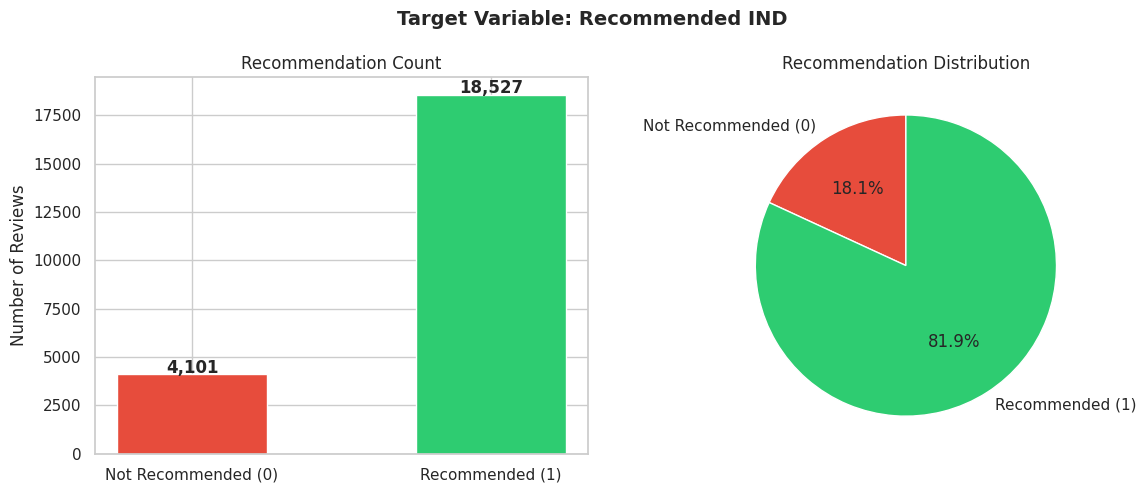

Recommendation rate: 81.9%


In [6]:
rec_counts = df['Recommended IND'].value_counts()
rec_labels = ['Not Recommended (0)', 'Recommended (1)']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(rec_labels, rec_counts.sort_index(), color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.5)
axes[0].set_title('Recommendation Count')
axes[0].set_ylabel('Number of Reviews')
for i, v in enumerate(rec_counts.sort_index()):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(rec_counts.sort_index(), labels=rec_labels, autopct='%1.1f%%',
            colors=['#e74c3c', '#2ecc71'], startangle=90)
axes[1].set_title('Recommendation Distribution')

plt.suptitle('Target Variable: Recommended IND', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Recommendation rate: {rec_counts[1]/len(df)*100:.1f}%")

### 4.2 Rating Distribution

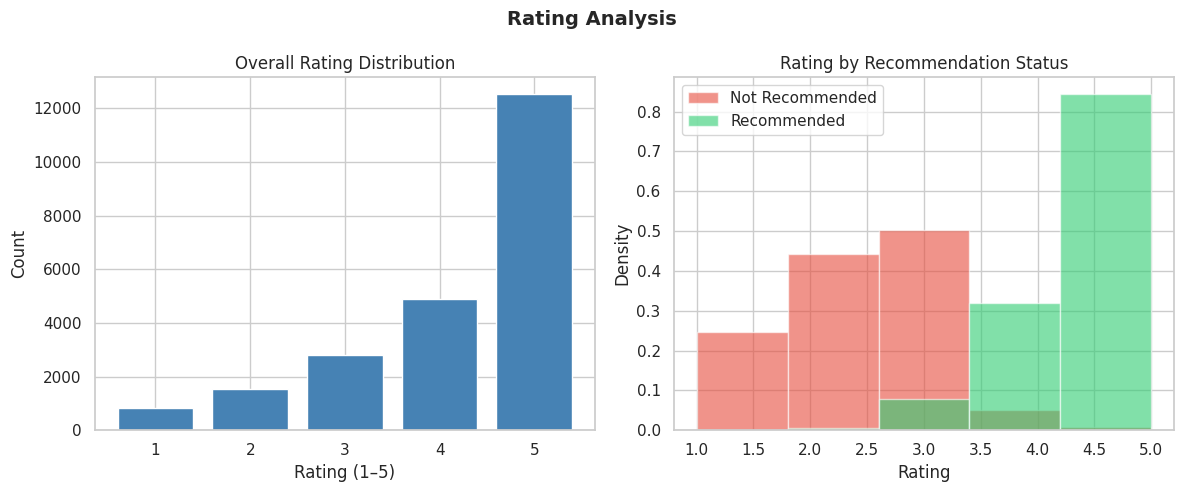

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Overall rating distribution
rating_counts = df['Rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Overall Rating Distribution')
axes[0].set_xlabel('Rating (1–5)')
axes[0].set_ylabel('Count')
axes[0].set_xticks([1,2,3,4,5])

# Rating by recommendation status
rec_0 = df[df['Recommended IND'] == 0]['Rating']
rec_1 = df[df['Recommended IND'] == 1]['Rating']
axes[1].hist(rec_0, bins=5, alpha=0.6, color='#e74c3c', label='Not Recommended', density=True)
axes[1].hist(rec_1, bins=5, alpha=0.6, color='#2ecc71', label='Recommended', density=True)
axes[1].set_title('Rating by Recommendation Status')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.suptitle('Rating Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Age Distribution

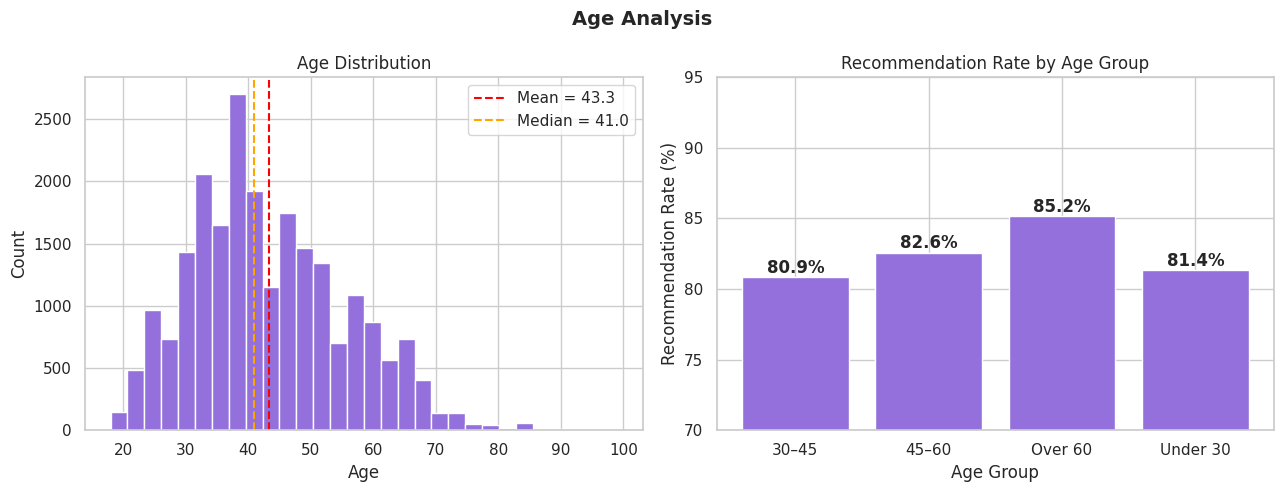

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram of age overall
axes[0].hist(df['Age'], bins=30, color='mediumpurple', edgecolor='white')
axes[0].axvline(df['Age'].mean(), color='red', linestyle='--', label=f"Mean = {df['Age'].mean():.1f}")
axes[0].axvline(df['Age'].median(), color='orange', linestyle='--', label=f"Median = {df['Age'].median():.1f}")
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# Age group vs recommendation rate
age_rec = df.groupby('Age Group')['Recommended IND'].mean() * 100
axes[1].bar(age_rec.index.astype(str), age_rec.values, color='mediumpurple', edgecolor='white')
axes[1].set_title('Recommendation Rate by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Recommendation Rate (%)')
axes[1].set_ylim(70, 95)
for i, v in enumerate(age_rec.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Age Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_age_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.4 Department & Division Analysis

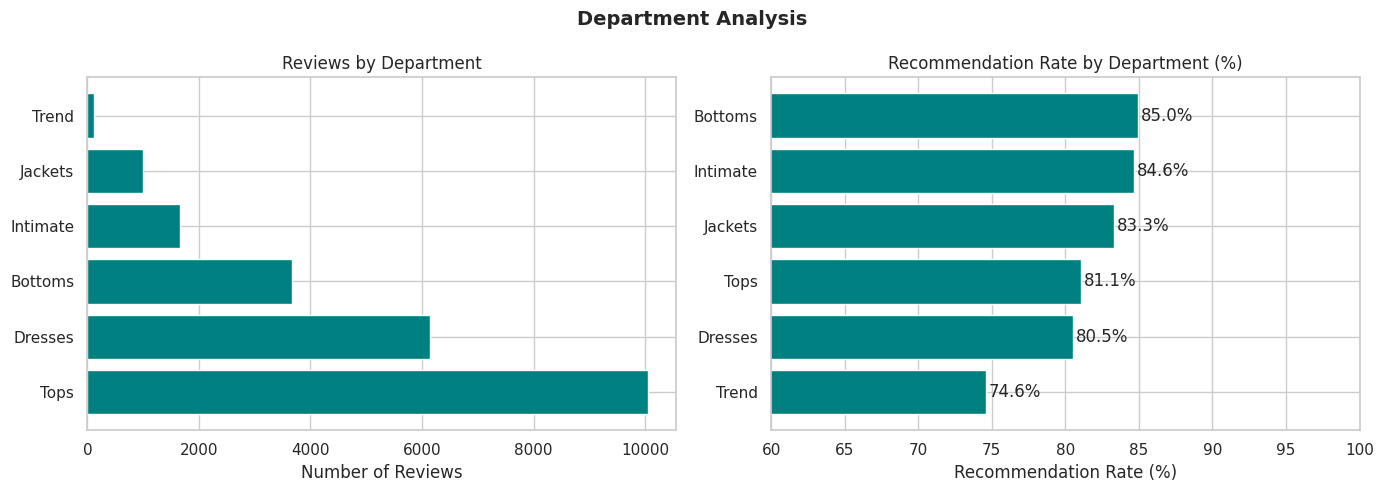

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Review count by Department
dept_counts = df['Department Name'].value_counts()
axes[0].barh(dept_counts.index, dept_counts.values, color='teal', edgecolor='white')
axes[0].set_title('Reviews by Department')
axes[0].set_xlabel('Number of Reviews')

# Recommendation rate by Department
dept_rec = df.groupby('Department Name')['Recommended IND'].mean().sort_values() * 100
axes[1].barh(dept_rec.index, dept_rec.values, color='teal', edgecolor='white')
axes[1].set_title('Recommendation Rate by Department (%)')
axes[1].set_xlabel('Recommendation Rate (%)')
axes[1].set_xlim(60, 100)
for i, v in enumerate(dept_rec.values):
    axes[1].text(v + 0.2, i, f'{v:.1f}%', va='center')

plt.suptitle('Department Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_department_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.5 Review Length Analysis

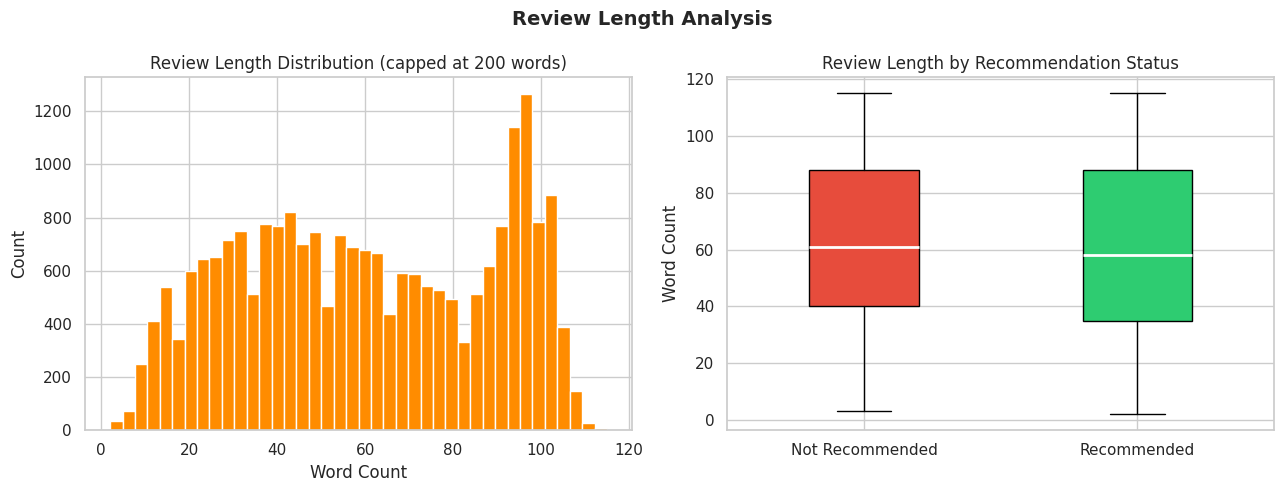

Mean review length – Not Recommended: 62.0
Mean review length – Recommended:     59.82


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Review length distribution (clipped for readability)
rl_clip = df['Review Length'].clip(upper=200)
axes[0].hist(rl_clip, bins=40, color='darkorange', edgecolor='white')
axes[0].set_title('Review Length Distribution (capped at 200 words)')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Count')

# Boxplot: review length by recommendation
data_rec = [df[df['Recommended IND'] == 0]['Review Length'].clip(upper=300),
            df[df['Recommended IND'] == 1]['Review Length'].clip(upper=300)]
bp = axes[1].boxplot(data_rec, patch_artist=True, widths=0.4,
                     medianprops={'color':'white','linewidth':2})
for patch, color in zip(bp['boxes'], ['#e74c3c','#2ecc71']):
    patch.set_facecolor(color)
axes[1].set_xticklabels(['Not Recommended', 'Recommended'])
axes[1].set_title('Review Length by Recommendation Status')
axes[1].set_ylabel('Word Count')

plt.suptitle('Review Length Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_review_length.png', dpi=150, bbox_inches='tight')
plt.show()

print('Mean review length – Not Recommended:', df[df['Recommended IND']==0]['Review Length'].mean().round(2))
print('Mean review length – Recommended:    ', df[df['Recommended IND']==1]['Review Length'].mean().round(2))

### 4.6 Sentiment Polarity Analysis

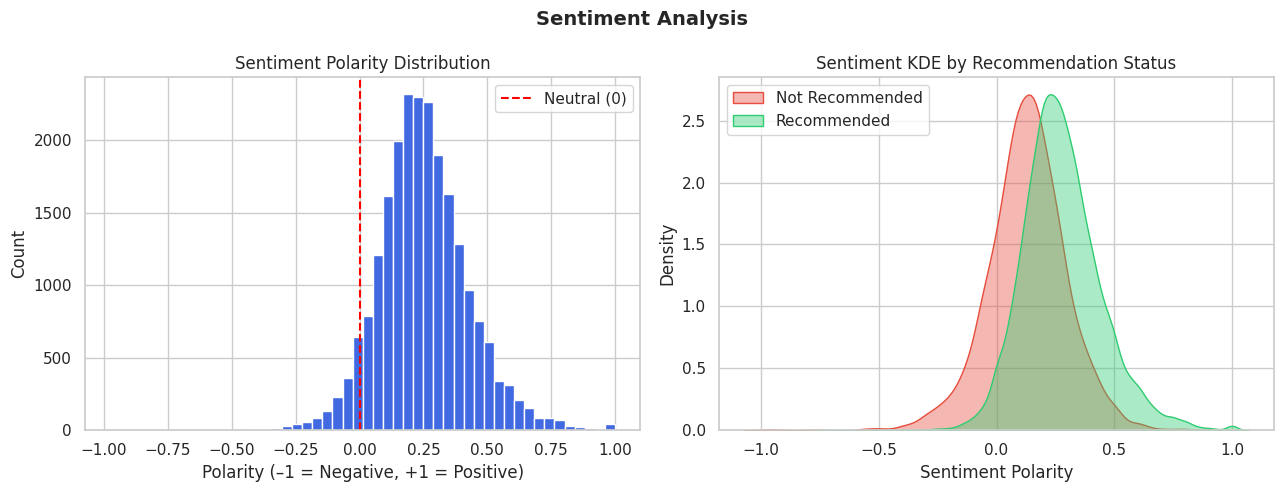

Mean sentiment – Not Recommended: 0.1293
Mean sentiment – Recommended:     0.2765


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Sentiment distribution overall
axes[0].hist(df['Sentiment'], bins=50, color='royalblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', label='Neutral (0)')
axes[0].set_title('Sentiment Polarity Distribution')
axes[0].set_xlabel('Polarity (–1 = Negative, +1 = Positive)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Sentiment by recommendation status
sns.kdeplot(df[df['Recommended IND']==0]['Sentiment'], ax=axes[1],
            color='#e74c3c', fill=True, alpha=0.4, label='Not Recommended')
sns.kdeplot(df[df['Recommended IND']==1]['Sentiment'], ax=axes[1],
            color='#2ecc71', fill=True, alpha=0.4, label='Recommended')
axes[1].set_title('Sentiment KDE by Recommendation Status')
axes[1].set_xlabel('Sentiment Polarity')
axes[1].legend()

plt.suptitle('Sentiment Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

print('Mean sentiment – Not Recommended:', df[df['Recommended IND']==0]['Sentiment'].mean().round(4))
print('Mean sentiment – Recommended:    ', df[df['Recommended IND']==1]['Sentiment'].mean().round(4))

### 4.7 Correlation Heatmap (Numeric Features)

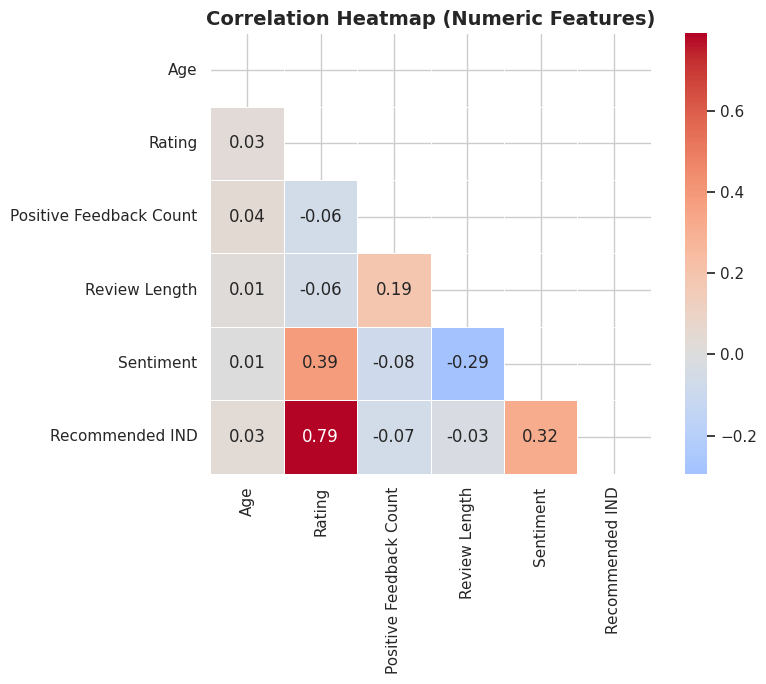

In [12]:
numeric_cols = ['Age', 'Rating', 'Positive Feedback Count', 'Review Length', 'Sentiment', 'Recommended IND']
corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, square=True, linewidths=0.5)
plt.title('Correlation Heatmap (Numeric Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.8 Pairplot (Key Features)

In [ ]:
pair_cols = ['Age', 'Rating', 'Sentiment', 'Review Length', 'Recommended IND']
pair_df = df[pair_cols].copy()
pair_df['Recommended IND'] = pair_df['Recommended IND'].map({0:'Not Recommended', 1:'Recommended'})

g = sns.pairplot(pair_df.sample(3000, random_state=42),
                 hue='Recommended IND',
                 palette={'Not Recommended':'#e74c3c', 'Recommended':'#2ecc71'},
                 plot_kws={'alpha': 0.3},
                 diag_kind='kde')
g.fig.suptitle('Pairplot of Key Features (sample n=3000)', y=1.01, fontsize=13, fontweight='bold')
plt.savefig('fig8_pairplot.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 5. Hypothesis Testing

All tests use **α = 0.05** as the significance level, as covered in course slides (Week 4 & Week 5).

**Decision rule:** If p-value < 0.05 → Reject H₀; otherwise → Fail to reject H₀.

---

### Hypothesis Test 1: Does Age Differ Between Recommenders and Non-Recommenders?
*Two-Sample Independent t-Test (Week 4 slides)*

- **H₀:** The mean age of recommending customers = mean age of non-recommending customers  
- **H₁:** The mean age of recommending customers ≠ mean age of non-recommending customers  
- **Assumption:** We check with Levene's test whether equal variance assumption holds.

In [ ]:
age_rec1 = df[df['Recommended IND'] == 1]['Age']
age_rec0 = df[df['Recommended IND'] == 0]['Age']

print(f"Recommended     → n={len(age_rec1):,}, mean={age_rec1.mean():.2f}, std={age_rec1.std():.2f}")
print(f"Not Recommended → n={len(age_rec0):,}, mean={age_rec0.mean():.2f}, std={age_rec0.std():.2f}")

# Levene's test for equal variance
levene_stat, levene_p = stats.levene(age_rec1, age_rec0)
print(f"\nLevene's test: stat={levene_stat:.4f}, p={levene_p:.4f}")
equal_var = levene_p > ALPHA
print(f"Equal variances assumed: {equal_var}")

# Two-sample t-test
t_stat, p_val = stats.ttest_ind(age_rec1, age_rec0, equal_var=equal_var)
print(f"\nTwo-sample t-test:")
print(f"  t-statistic = {t_stat:.4f}")
print(f"  p-value     = {p_val:.6f}")

if p_val < ALPHA:
    print(f"  → p < α={ALPHA}: REJECT H₀ — There IS a statistically significant difference in age.")
else:
    print(f"  → p ≥ α={ALPHA}: FAIL TO REJECT H₀ — No significant age difference.")

In [ ]:
# Visualise – boxplot of age by recommendation
fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot([age_rec0, age_rec1], patch_artist=True, widths=0.5,
                medianprops={'color':'white','linewidth':2})
for patch, c in zip(bp['boxes'], ['#e74c3c','#2ecc71']):
    patch.set_facecolor(c)
ax.set_xticklabels(['Not Recommended (0)', 'Recommended (1)'], fontsize=12)
ax.set_ylabel('Age')
ax.set_title('HT1: Age by Recommendation Status\n'
             f'Two-sample t-test: t={t_stat:.3f}, p={p_val:.4f}', fontsize=12)
ax.text(0.98, 0.97,
        f"{'REJECT H₀' if p_val < ALPHA else 'FAIL TO REJECT H₀'} (α=0.05)",
        transform=ax.transAxes, ha='right', va='top',
        fontweight='bold', color='red' if p_val < ALPHA else 'green')
plt.tight_layout()
plt.savefig('fig9_ht1_age.png', dpi=150, bbox_inches='tight')
plt.show()

### Hypothesis Test 2: Does Sentiment Differ Between Recommenders and Non-Recommenders?
*Two-Sample Independent t-Test (Week 4 slides)*

- **H₀:** Mean sentiment polarity of recommenders = mean sentiment polarity of non-recommenders  
- **H₁:** Mean sentiment polarity of recommenders > mean sentiment polarity of non-recommenders *(one-tailed)*

In [ ]:
sent_rec1 = df[df['Recommended IND'] == 1]['Sentiment']
sent_rec0 = df[df['Recommended IND'] == 0]['Sentiment']

print(f"Recommended     → mean sentiment = {sent_rec1.mean():.4f}")
print(f"Not Recommended → mean sentiment = {sent_rec0.mean():.4f}")

# One-tailed t-test (testing: rec > not rec)
t_stat2, p_two = stats.ttest_ind(sent_rec1, sent_rec0, equal_var=False)
p_one = p_two / 2  # one-tailed p-value

print(f"\nWelch's t-test (one-tailed):")
print(f"  t-statistic       = {t_stat2:.4f}")
print(f"  p-value (1-tailed)= {p_one:.6e}")

if p_one < ALPHA and t_stat2 > 0:
    print(f"  → REJECT H₀ — Recommenders write significantly MORE POSITIVE reviews.")
else:
    print(f"  → FAIL TO REJECT H₀")

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.kdeplot(sent_rec0, ax=ax, color='#e74c3c', fill=True, alpha=0.5, label=f'Not Recommended (mean={sent_rec0.mean():.3f})')
sns.kdeplot(sent_rec1, ax=ax, color='#2ecc71', fill=True, alpha=0.5, label=f'Recommended (mean={sent_rec1.mean():.3f})')
ax.axvline(sent_rec0.mean(), color='#e74c3c', linestyle='--', linewidth=1.5)
ax.axvline(sent_rec1.mean(), color='#2ecc71', linestyle='--', linewidth=1.5)
ax.set_xlabel('Sentiment Polarity')
ax.set_title('HT2: Sentiment by Recommendation Status\n'
             f'Welch\'s t-test (1-tailed): t={t_stat2:.3f}, p={p_one:.2e}', fontsize=12)
ax.legend()
ax.text(0.98, 0.97, 'REJECT H₀ (α=0.05)', transform=ax.transAxes,
        ha='right', va='top', fontweight='bold', color='red')
plt.tight_layout()
plt.savefig('fig10_ht2_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

### Hypothesis Test 3: Does Mean Rating Differ Across Departments?
*One-Way ANOVA (Week 4b slides)*

- **H₀:** Mean rating is the same across all departments (μ₁ = μ₂ = … = μₖ)  
- **H₁:** At least one department has a different mean rating

In [ ]:
dept_groups = [group['Rating'].values for _, group in df.groupby('Department Name')]
dept_names  = df['Department Name'].unique()

print("Group means:")
for name, g in zip(df['Department Name'].unique(), dept_groups):
    print(f"  {name:15s}: n={len(g):5,}, mean={g.mean():.3f}, std={g.std():.3f}")

f_stat, p_anova = stats.f_oneway(*dept_groups)
print(f"\nOne-Way ANOVA:")
print(f"  F-statistic = {f_stat:.4f}")
print(f"  p-value     = {p_anova:.6e}")

if p_anova < ALPHA:
    print(f"  → REJECT H₀ — At least one department has a significantly different mean rating.")
else:
    print(f"  → FAIL TO REJECT H₀")

In [ ]:
# Post-hoc: mean + CI bar chart per department
dept_stats = df.groupby('Department Name')['Rating'].agg(['mean','std','count'])
dept_stats['se'] = dept_stats['std'] / np.sqrt(dept_stats['count'])
dept_stats = dept_stats.sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(dept_stats.index, dept_stats['mean'],
        xerr=dept_stats['se']*1.96, color='steelblue', edgecolor='white',
        error_kw={'capsize':5, 'color':'black'})
ax.axvline(df['Rating'].mean(), color='red', linestyle='--', label=f'Overall mean={df["Rating"].mean():.2f}')
ax.set_xlabel('Mean Rating')
ax.set_xlim(3.5, 4.5)
ax.set_title('HT3: Mean Rating by Department (with 95% CI)\n'
             f'One-Way ANOVA: F={f_stat:.2f}, p={p_anova:.2e}', fontsize=12)
ax.legend()
ax.text(0.98, 0.04, 'REJECT H₀ (α=0.05)', transform=ax.transAxes,
        ha='right', va='bottom', fontweight='bold', color='red')
plt.tight_layout()
plt.savefig('fig11_ht3_anova.png', dpi=150, bbox_inches='tight')
plt.show()

### Hypothesis Test 4: Do Recommenders Write Longer Reviews?
*Two-Sample Independent t-Test (Week 4 slides)*

- **H₀:** Mean review length of recommenders = mean review length of non-recommenders  
- **H₁:** Mean review length of recommenders ≠ mean review length of non-recommenders

In [ ]:
rl_rec1 = df[df['Recommended IND'] == 1]['Review Length']
rl_rec0 = df[df['Recommended IND'] == 0]['Review Length']

print(f"Recommended     → mean = {rl_rec1.mean():.2f} words")
print(f"Not Recommended → mean = {rl_rec0.mean():.2f} words")

t_stat4, p_val4 = stats.ttest_ind(rl_rec1, rl_rec0, equal_var=False)
print(f"\nWelch's t-test:")
print(f"  t-statistic = {t_stat4:.4f}")
print(f"  p-value     = {p_val4:.6f}")

if p_val4 < ALPHA:
    print(f"  → REJECT H₀ — Review length differs significantly between groups.")
else:
    print(f"  → FAIL TO REJECT H₀")

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(rl_rec0.clip(upper=300), bins=40, alpha=0.6, color='#e74c3c',
        density=True, label=f'Not Recommended (mean={rl_rec0.mean():.1f})')
ax.hist(rl_rec1.clip(upper=300), bins=40, alpha=0.6, color='#2ecc71',
        density=True, label=f'Recommended (mean={rl_rec1.mean():.1f})')
ax.axvline(rl_rec0.mean(), color='#e74c3c', linestyle='--', linewidth=2)
ax.axvline(rl_rec1.mean(), color='#2ecc71', linestyle='--', linewidth=2)
ax.set_xlabel('Review Length (words)')
ax.set_title('HT4: Review Length by Recommendation Status\n'
             f'Welch\'s t-test: t={t_stat4:.3f}, p={p_val4:.4f}', fontsize=12)
ax.legend()
ax.text(0.98, 0.97,
        f"{'REJECT H₀' if p_val4 < ALPHA else 'FAIL TO REJECT H₀'} (α=0.05)",
        transform=ax.transAxes, ha='right', va='top',
        fontweight='bold', color='red' if p_val4 < ALPHA else 'green')
plt.tight_layout()
plt.savefig('fig12_ht4_reviewlen.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Summary of Hypothesis Test Results

In [ ]:
summary = pd.DataFrame({
    'Test': ['HT1: Age (rec vs. not rec)',
             'HT2: Sentiment (rec vs. not rec)',
             'HT3: Rating across Departments',
             'HT4: Review Length (rec vs. not rec)'],
    'Method': ['Two-sample t-test', 'Welch\'s t-test (1-tailed)',
               'One-Way ANOVA', 'Welch\'s t-test'],
    'Statistic': [round(t_stat, 4), round(t_stat2, 4),
                  round(f_stat, 4), round(t_stat4, 4)],
    'p-value':   [round(p_val, 6), round(p_one, 6),
                  round(p_anova, 6), round(p_val4, 6)],
    'Decision':  ['Reject H₀' if p_val  < ALPHA else 'Fail to Reject H₀',
                  'Reject H₀' if p_one  < ALPHA else 'Fail to Reject H₀',
                  'Reject H₀' if p_anova< ALPHA else 'Fail to Reject H₀',
                  'Reject H₀' if p_val4 < ALPHA else 'Fail to Reject H₀']
})

print(summary.to_string(index=False))

---
## 7. Key EDA Findings

| Observation | Finding |
|---|---|
| **Class imbalance** | ~82% of reviews are positive recommendations — the dataset is imbalanced. This matters for the ML phase. |
| **Rating** | Strongly correlated with recommendation (r ≈ 0.79). High-rated products are almost always recommended. |
| **Sentiment** | Recommenders write significantly more positive reviews. Sentiment is a strong feature candidate. |
| **Age** | Small but statistically significant age difference; recommenders are slightly older on average. |
| **Review Length** | Non-recommenders write longer reviews — possibly because dissatisfied customers elaborate more. |
| **Department** | Trend and Jackets departments have the lowest recommendation rates; Intimate tops them. |

---
## 8. Save Enriched Dataset for Next Phase

In [ ]:
df.to_csv('data_enriched.csv', index=False)
print(f'Saved data_enriched.csv — shape: {df.shape}')
print('Columns:', df.columns.tolist())